In [1]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langchain_groq import ChatGroq
from dotenv import load_dotenv
import os

c:\Users\MOHIT\Desktop\llm ai l\lang graph\langgen\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
load_dotenv()

True

subgraph

In [3]:
class SubState(TypedDict):

    input_text: str
    translated_text: str

In [ ]:
groq_api_key = os.getenv("GROQ_API_KEY")

subgraph_llm = ChatGroq(
    model="openai/gpt-oss-20b",
    temperature=0.5,
    groq_api_key=groq_api_key
)

In [5]:
def translate_text(state: SubState):

    prompt = f"""
Translate the following text to Hindi.
Keep it natural and clear. Do not add extra content.

Text:
{state["input_text"]}
""".strip()
    
    translated_text = subgraph_llm.invoke(prompt).content

    return {'translated_text': translated_text}

In [6]:
subgraph_builder = StateGraph(SubState)

subgraph_builder.add_node('translate_text', translate_text)

subgraph_builder.add_edge(START, 'translate_text')
subgraph_builder.add_edge('translate_text', END)

subgraph = subgraph_builder.compile()

parentgraph

In [7]:
class ParentState(TypedDict):

    question: str
    answer_eng: str
    answer_hin: str

In [8]:
groq_api_key = os.getenv("GROQ_API_KEY")

parent_llm = ChatGroq(
    model="openai/gpt-oss-20b",
    temperature=0.5,
    groq_api_key=groq_api_key
)

In [9]:
def generate_answer(state: ParentState):

    answer = parent_llm.invoke(f"You are a helpful assistant. Answer clearly.\n\nQuestion: {state['question']}").content
    return {'answer_eng': answer}

In [10]:
def translate_answer(state: ParentState):

    # call the subgraph
    result = subgraph.invoke({'input_text': state['answer_eng']})

    return {'answer_hin': result['translated_text']}

In [11]:
parent_builder = StateGraph(ParentState)

parent_builder.add_node("answer", generate_answer)
parent_builder.add_node("translate", translate_answer)

parent_builder.add_edge(START, 'answer')
parent_builder.add_edge('answer', 'translate')
parent_builder.add_edge('translate', END)

In [12]:
graph = parent_builder.compile()

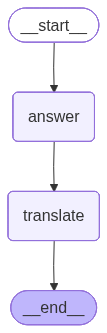

In [13]:
graph

In [15]:
graph.invoke({'question': 'What is emergent behavior of neural networks?'})

{'question': 'What is emergent behavior of neural networks?',
 'answer_eng': '**Emergent behavior** in neural networks refers to complex, often surprising, properties or capabilities that arise *spontaneously* from the interaction of many simple, individually‑behaving units (neurons) during training and inference—without those properties being explicitly programmed or hard‑coded into the model.\n\n---\n\n### Why it matters\n\n* **Complexity from simplicity** – Each neuron performs a simple weighted sum and non‑linear activation, but when millions of them are connected, the network can develop sophisticated internal representations that were not designed by a human.\n* **Unpredictability** – Because the behavior emerges from the training data and optimization process, it can be hard to anticipate all the ways a model will respond to new inputs.\n* **Power and risk** – Emergent capabilities can be useful (e.g., language understanding, image synthesis) but can also lead to undesirable sid